# Notebook 1: Dataset Selection & Quick Check

## Project: Team Communication Analysis  
### GSoC 2026 — HumanAI / TRIP Lab Task

This notebook selects a public audio dataset and does a small evaluation to see if it is suitable for analyzing team communication recordings.

In [1]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import matplotlib
import warnings

warnings.filterwarnings("ignore")

# default plot size
matplotlib.rcParams["figure.figsize"] = (14, 4)

print("Libraries loaded")

Libraries loaded


## 1. Dataset Chosen: AMI Meeting Corpus

Source: [https://groups.inf.ed.ac.uk/ami/corpus/]

### Why I picked this dataset

The AMI Meeting Corpus is suitable for this project because it contains recordings of real meetings with multiple speakers (usually 3–5 people).

Some reasons I chose it:

- Free for academic research
- Contains real conversations instead of scripted audio
- Provides multiple resources:
  - audio files (.wav)
  - transcripts
  - speaker annotations
- Large dataset (~100+ hours of meetings)
- Commonly used in research for speech and meeting analysis

### How I plan to use it

- Use the audio recordings to test audio enhancement methods
- Use the transcripts to check if speech recognition improves after enhancement
- The recordings also include natural noise, room effects, and overlapping speech, which makes them useful for realistic scenarios

### Why it fits this project

This dataset focuses on multi-speaker meetings and team communication.  
The conversations include coordination, instructions, interruptions, and overlapping speech, which are common in real team environments.

Because of this, it is a good match for studying communication in simulated team settings like those in TRIP Lab.

In [2]:
from datasets import load_dataset, Audio
import soundfile as sf
import librosa
import numpy as np
import os

print("Loading AMI dataset...")

ds = load_dataset(
    "edinburghcstr/ami",
    "ihm",
    split="train",
    streaming=True
)

# ensure audio format
ds = ds.cast_column("audio", Audio(sampling_rate=16000, decode=False))

sr = 16000
target_sec = 180  # ~3 min
audio_parts = []
total_dur = 0
info = []

print("Collecting audio segments...")

for i, s in enumerate(ds):
    try:
        path = s["audio"]["path"]
        data = s["audio"]["bytes"]

        tmp = f"tmp_{i}.wav"
        with open(tmp, "wb") as f:
            f.write(data)

        y, file_sr = sf.read(tmp)
        os.remove(tmp)

        # convert stereo → mono
        if len(y.shape) > 1:
            y = np.mean(y, axis=1)

        y = y.astype(np.float32)

        # resample if needed
        if file_sr != sr:
            y = librosa.resample(y, orig_sr=file_sr, target_sr=sr)

        dur = len(y) / sr
        audio_parts.append(y)
        total_dur += dur

        info.append({
            "meeting": s.get("meeting_id", f"m{i}"),
            "speaker": s.get("speaker_id", f"s{i}"),
            "text": s.get("text", ""),
            "dur": round(dur, 2)
        })

        print(f"seg {i+1} | {total_dur:.1f}/{target_sec}s", end="\r")

        if total_dur >= target_sec:
            break

    except Exception:
        continue

print(f"\nCollected {len(info)} segments")

# merge audio and trim to 3 min
y = np.concatenate(audio_parts)
y = y[:sr * target_sec]

out_file = "sample_input.wav"
sf.write(out_file, y, sr)

print("\nSaved:", out_file)
print("SR:", sr, "Hz")
print("Duration:", round(len(y)/sr, 1), "s")
print("Segments:", len(info))

print("\nExample utterances:")
for x in info[:5]:
    print(f"[{x['meeting']} | {x['speaker']}] {x['text'][:60]} ({x['dur']}s)")

Loading AMI dataset...


Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42 [00:00<?, ?it/s]

seg 58 | 180.0/180s
Collected 58 segments

Saved: sample_input.wav
SR: 16000 Hz
Duration: 180.0 s
Segments: 58

Example utterances:
[EN2001a | MEO069] IF YOU IF YOU S. S. H. AND THEY HAVE THIS BIG WARNING ABOUT  (4.21s)
[EN2001a | MEE068] I'VE GOTTEN MM HARDLY ANY (1.63s)
[EN2001a | MEE067] IT'S YEAH I MEAN THE WAVE DATA ARE OBVIOUSLY NOT GONNA GET O (5.25s)
[EN2001a | MEO069] YEAH IT'LL IT'LL PLAY THEM IN SOME ORDER IN WHICH THEY WERE  (6.37s)
[EN2001a | MEE067] YEAH (0.37s)


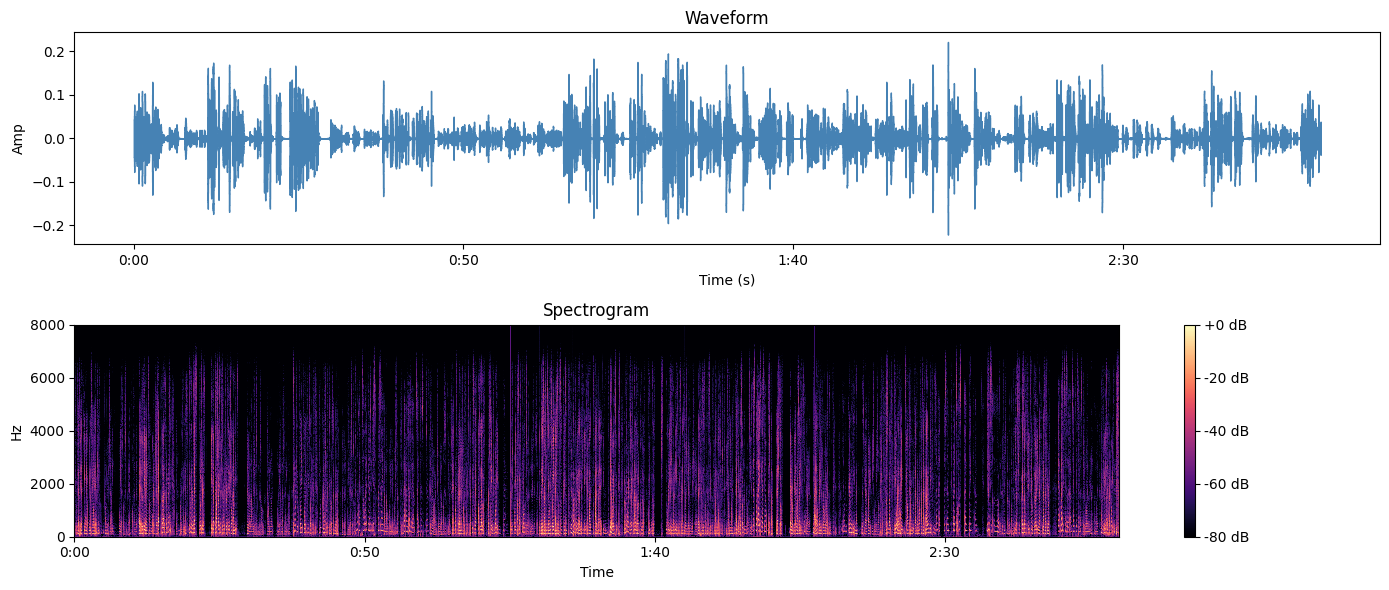

Plot saved


In [3]:
# waveform and spectrogram
fig, ax = plt.subplots(2, 1, figsize=(14, 6))

# waveform
ax[0].set_title("Waveform")
librosa.display.waveshow(y, sr=sr, ax=ax[0], color="steelblue")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amp")

# spectrogram
S = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
img = librosa.display.specshow(S, sr=sr, x_axis="time", y_axis="hz", ax=ax[1], cmap="magma")
ax[1].set_title("Spectrogram")
plt.colorbar(img, ax=ax[1], format="%+2.0f dB")

plt.tight_layout()
plt.savefig("sample_waveform_spectrogram.png", dpi=150)
plt.show()

print("Plot saved")

In [5]:
# basic audio stats
rms = np.sqrt(np.mean(y**2))

zcr = np.mean(librosa.feature.zero_crossing_rate(y))

centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))

# estimate duration
duration = len(y) / sr

# rough SNR estimate
sig_power = np.mean(y**2)
noise_power = np.mean(y[:sr//4]**2)
snr = 10 * np.log10(sig_power / (noise_power + 1e-10))

print("="*40)
print("Audio Sample Report")
print("="*40)
print("Sample Rate :", sr, "Hz")
print("Duration    :", round(duration, 2), "sec")
print("RMS Energy  :", round(rms, 4))
print("ZCR         :", round(zcr, 4))
print("Centroid    :", round(centroid, 1), "Hz")
print("Est. SNR    :", round(snr, 1), "dB")
print("="*40)

Audio Sample Report
Sample Rate : 16000 Hz
Duration    : 180.0 sec
RMS Energy  : 0.0125
ZCR         : 0.0958
Centroid    : 1312.0 Hz
Est. SNR    : -1.4 dB


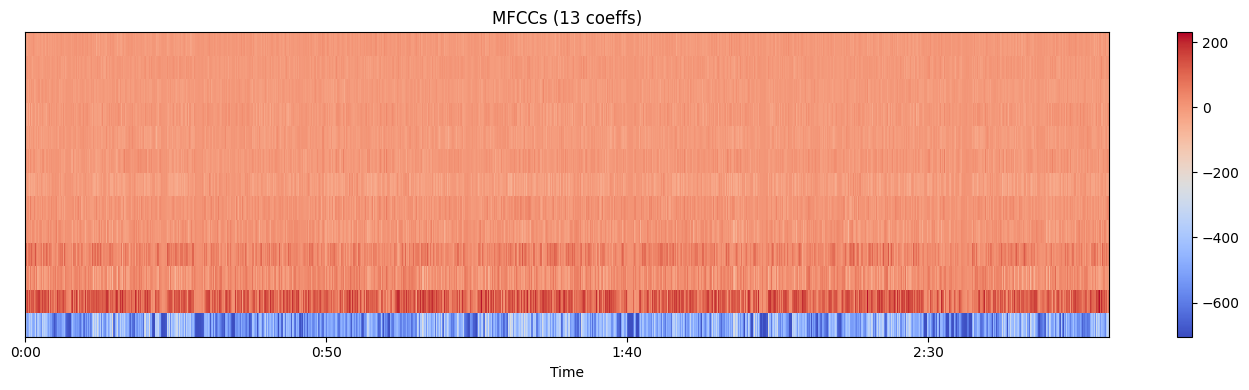

MFCC plot saved


In [6]:
# compute MFCC features
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

plt.figure(figsize=(14,4))
librosa.display.specshow(mfcc, x_axis="time", sr=sr, cmap="coolwarm")
plt.colorbar()
plt.title("MFCCs (13 coeffs)")

plt.tight_layout()
plt.savefig("sample_mfcc.png", dpi=150)
plt.show()

print("MFCC plot saved")

## Conclusion

The AMI Meeting Corpus fits this project well for a few main reasons:

- It contains real meeting conversations, which are similar to the type of team communication studied in TRIP Lab.
- The recordings include both cleaner and noisier audio, which helps when testing audio enhancement methods.
- The dataset is large (100+ hours), so it provides enough material for experiments.
- It is openly available for research use.
- It also includes speaker-level transcripts, which makes it easier to evaluate improvements in transcription.

### Next Step

In the next notebook, I will apply some audio enhancement techniques on selected audio samples and analyze how much the audio quality improves.